In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [7]:
# 1 Generar datos aleatorios con distribución normal
ruta = "C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/Clientes_Dos_Mil_numeros.csv"
df = pd.read_csv(ruta)
dataframe = df

In [8]:
# 1.1 quitar la variable dependiente "Y"
df = dataframe.drop(['Y'], axis=1) 

In [9]:
# 1) Centrar los datos (restar la media de cada columna)
df_centered = df - df.mean()

In [10]:
# 2) Calcular la matriz de covarianza con los datos centrados
A = df_centered.cov()

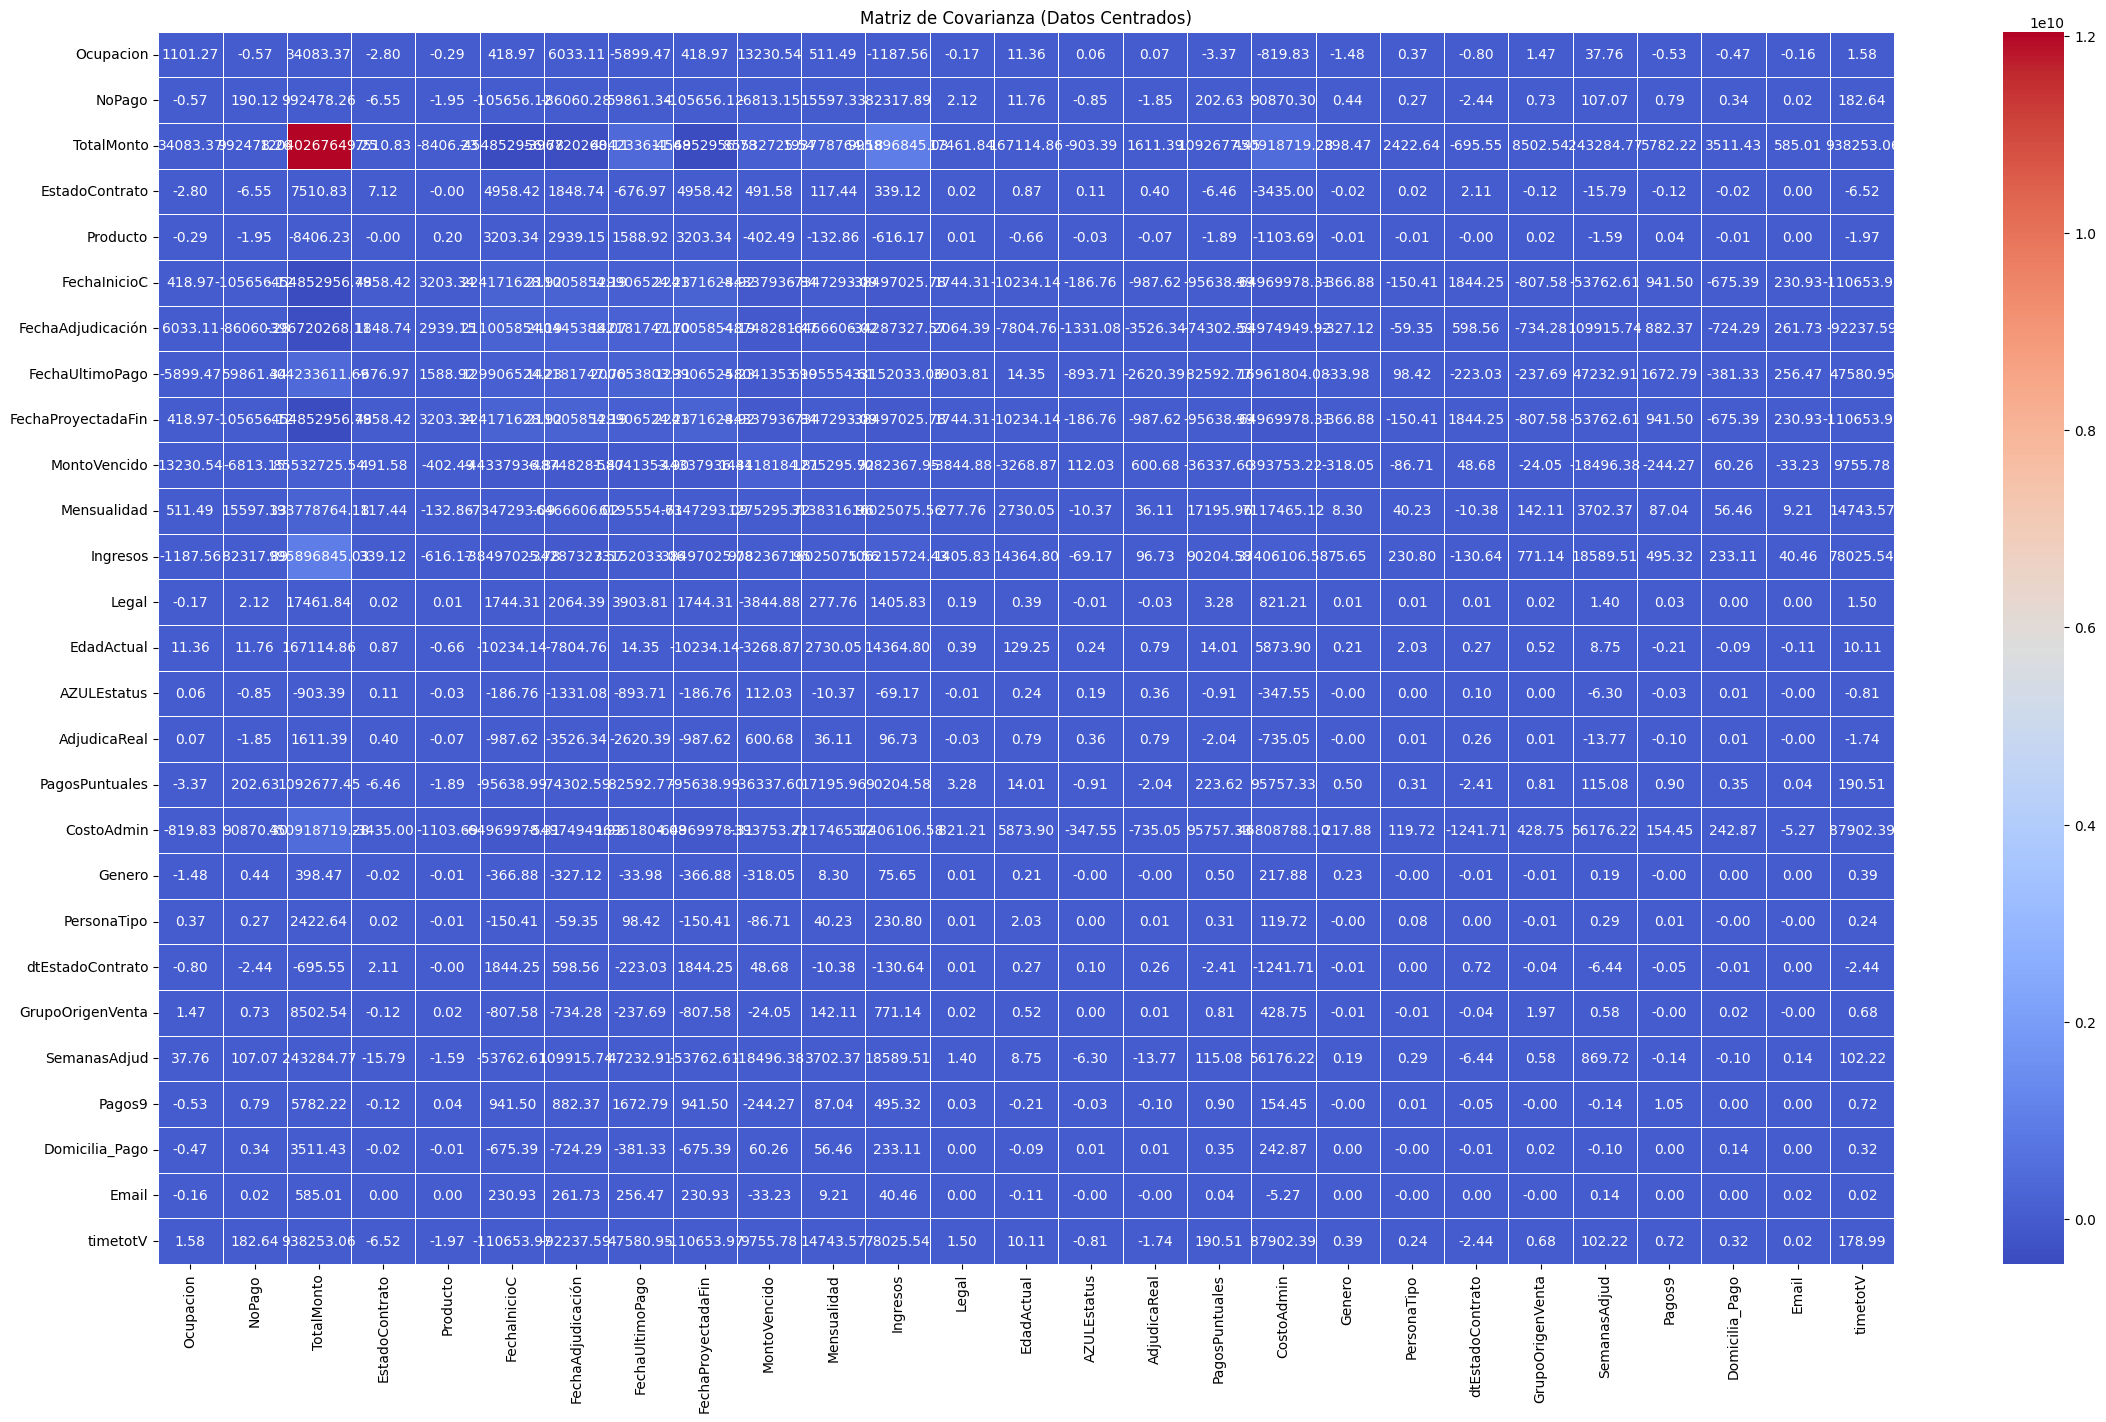

In [ ]:
# 2.1) Graficar la matriz de covarianza
plt.figure(figsize=(28, 16))
sns.heatmap(A, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de covarianza (datos centrados)")
plt.show()

In [15]:
# 3) Descomposición SVD
U, S, Vt = np.linalg.svd(A)

In [16]:
# Mostramos cada matriz
print("Matriz U (Autovectores de la matriz de covarianza):\n", U)
print("Valores singulares S (raíz cuadrada de los autovalores de A):\n", S)
print("Matriz V traspuesta:\n", Vt)

Matriz U (Autovectores de la matriz de covarianza):
 [[-2.73564628e-06  1.13388405e-06  1.07977236e-04  1.97965724e-05
   2.33731316e-04 -1.38359533e-04 -6.31309327e-04 -2.06106740e-03
  -9.99884347e-01 -8.85272051e-03  1.14362838e-02 -2.55353032e-03
   2.43538068e-03 -1.19156231e-03 -8.26603250e-04 -6.84139914e-04
  -5.81606865e-04 -9.16596960e-05 -1.32845857e-03 -4.78322162e-05
  -4.41250987e-04 -6.75260586e-05 -1.55715167e-04 -1.56587564e-04
  -2.96420769e-05 -1.24017842e-04  7.98974592e-14]
 [-8.26756720e-05 -1.13902501e-04 -4.27828504e-04 -8.72238736e-04
   5.22267625e-05 -2.13064290e-05 -1.40282950e-03 -4.85720541e-03
  -1.29504339e-03  1.06137626e-02  4.95168538e-03  5.69105779e-01
   2.22737859e-02  6.73209877e-03 -9.23317825e-02 -2.24730784e-02
  -1.85176312e-02 -8.06716458e-01  2.22821588e-02 -6.12410616e-03
  -2.13357869e-02 -1.13730354e-02  4.19761421e-03  1.18656126e-01
   2.58738125e-03 -5.00983882e-03  1.28059375e-10]
 [-9.93070061e-01  4.89058504e-02  2.74935047e-02  6.

In [17]:
# 4) Cálculo de Componentes Principales
# Proyectamos los datos centrados en los nuevos ejes
Z = df_centered @ Vt.T  # Transformación de datos originales a espacio PCA

In [ ]:
# Explicación
var_explicada = S / np.sum(S) * 100  # Porcentaje de varianza explicada por cada componente
print("Varianza Explicada por cada componente:\n", var_explicada)

Varianza Explicada por cada componente:
 [9.22640056e+01 5.69474394e+00 1.07836978e+00 5.54441729e-01
 2.07548605e-01 1.78040271e-01 2.27026696e-02 1.36567061e-04
 8.28784255e-06 1.32768245e-06 9.53892463e-07 1.95245366e-07
 5.28650015e-08 1.47676922e-08 1.24821581e-08 7.87702606e-09
 4.99580511e-09 1.86875079e-09 1.66534102e-09 1.05544854e-09
 1.01719131e-09 4.63886771e-10 3.77928833e-10 2.20189592e-10
 1.63509947e-10 1.35514468e-10 8.19316964e-15]


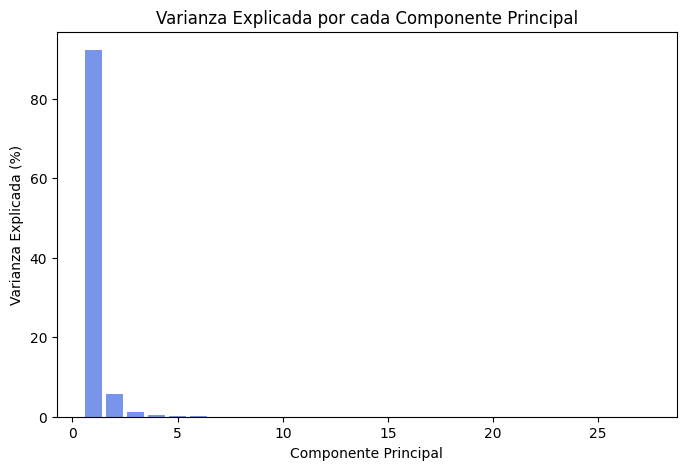

In [19]:
# Graficamos la varianza explicada
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(var_explicada) + 1), var_explicada, color='royalblue', alpha=0.7)
plt.xlabel("Componente Principal")
plt.ylabel("Varianza Explicada (%)")
plt.title("Varianza Explicada por cada Componente Principal")
plt.show()

In [20]:
print("Valores singulares S (raíz cuadrada de los autovalores de A):\n", S)

Valores singulares S (raíz cuadrada de los autovalores de A):
 [1.22065222e+10 7.53414271e+08 1.42668255e+08 7.33526065e+07
 2.74586677e+07 2.35547168e+07 3.00356179e+06 1.80678138e+04
 1.09648106e+03 1.75652306e+02 1.26199914e+02 2.58309499e+01
 6.99403643e+00 1.95376476e+00 1.65138875e+00 1.04213006e+00
 6.60944707e-01 2.47235614e-01 2.20324514e-01 1.39635777e-01
 1.34574347e-01 6.13721912e-02 4.99999613e-02 2.91310694e-02
 2.16323559e-02 1.79285557e-02 1.08395584e-06]


In [21]:
# Relación entre variables originales y componentes principales
loading_matrix = Vt.T  # Transponer para que filas correspondan a variables originales

# Crear un DataFrame para facilitar la visualización
loading_df = pd.DataFrame(loading_matrix, 
                          index=df.columns, 
                          columns=[f"PC{i+1}" for i in range(len(df.columns))])

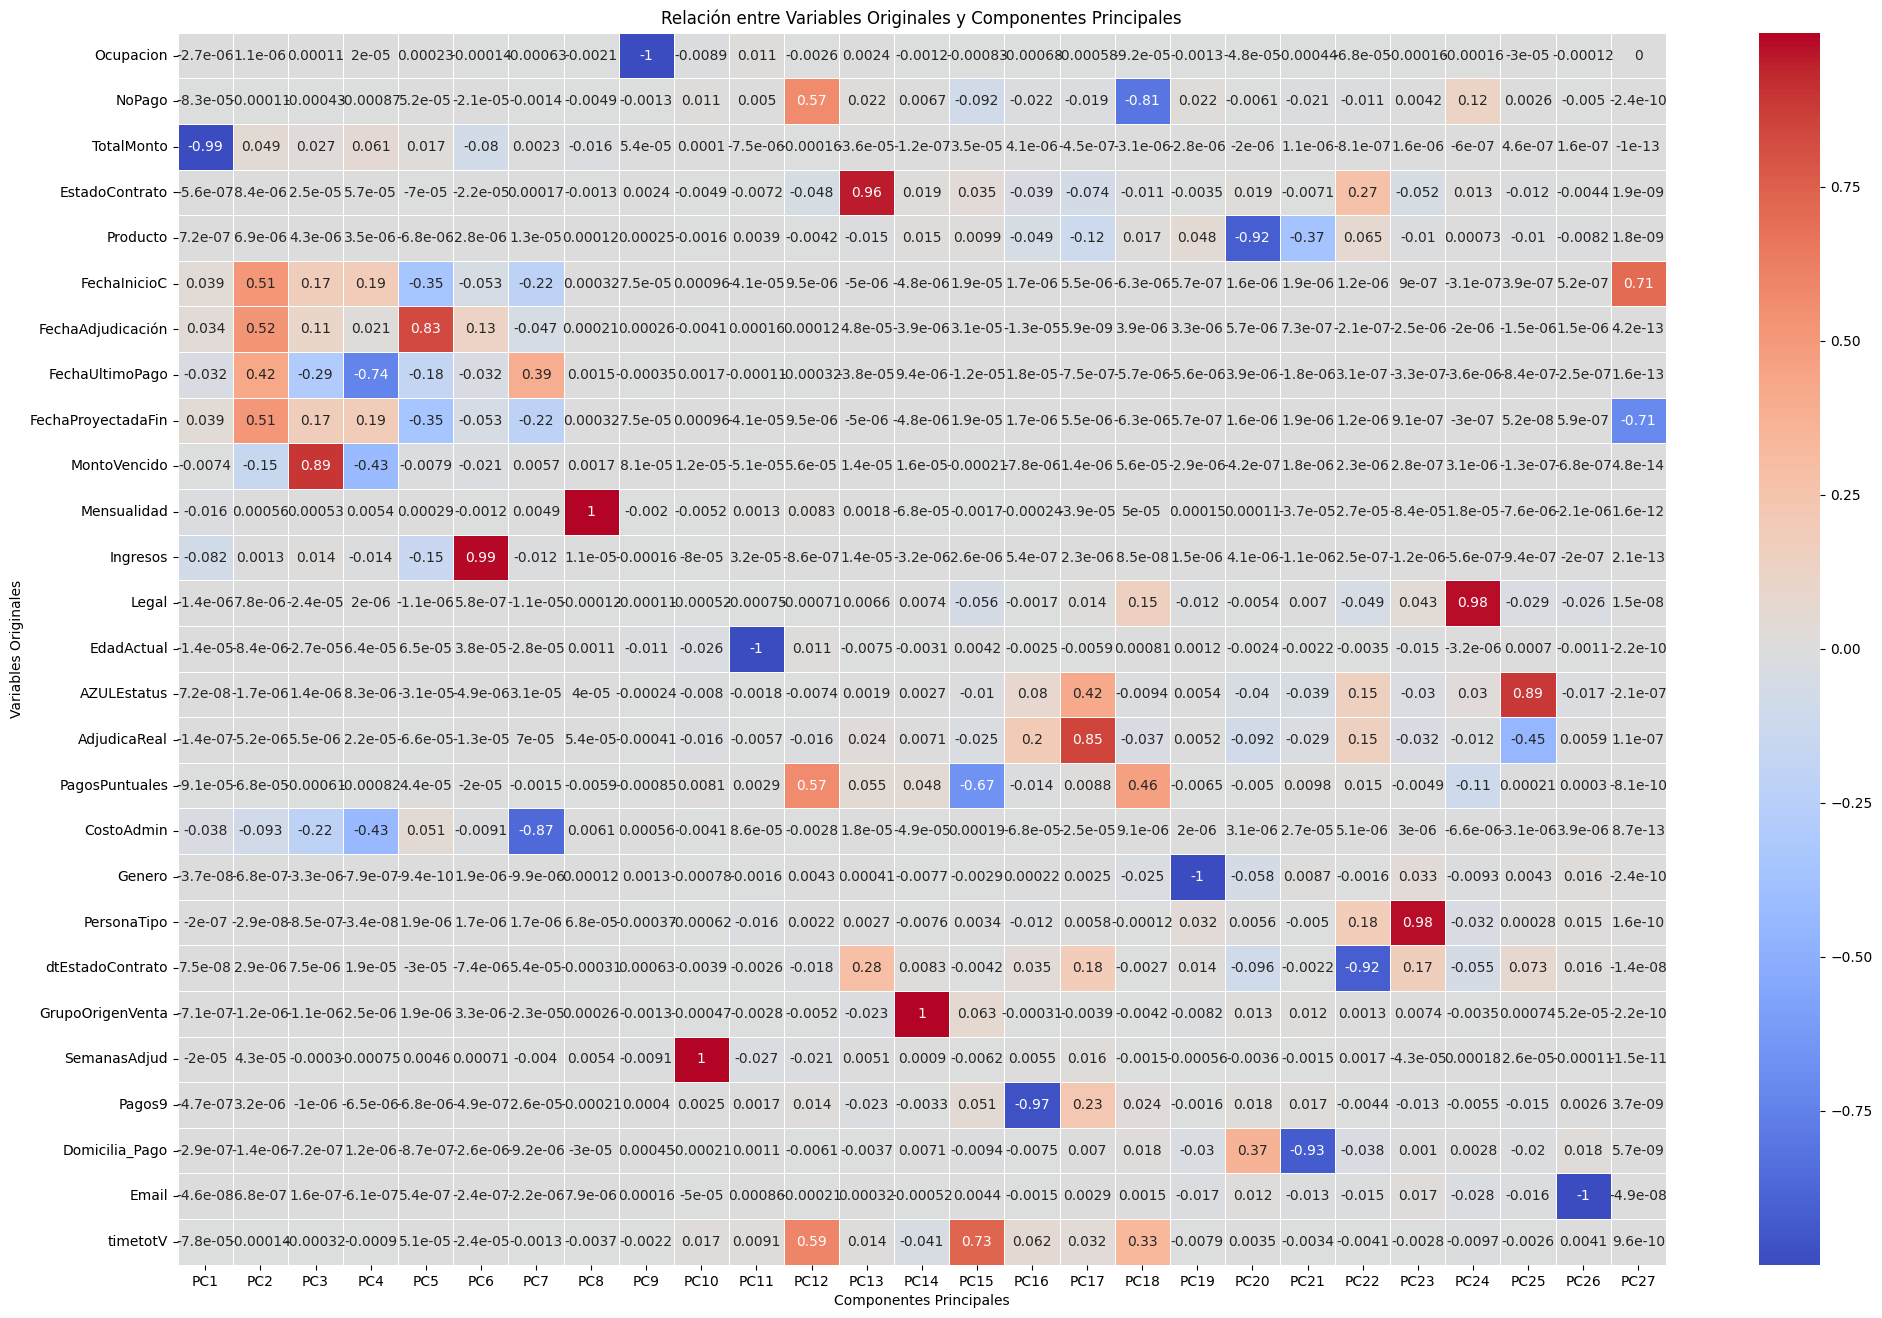

In [24]:
# Gráfico Heatmap
plt.figure(figsize=(24, 16))
sns.heatmap(loading_df, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Relación entre Variables Originales y Componentes Principales")
plt.xlabel("Componentes Principales")
plt.ylabel("Variables Originales")
plt.show()

In [29]:
loading_matrix = Vt.T  # Transponer para que las filas correspondan a variables originales

In [31]:
# Identificar las variables más influyentes en cada PCA
top_variables = {}

for component in loading_df.columns:
    top_var = loading_df[component].abs().nlargest(3).index.tolist()  # Top 3 por magnitud
    top_variables[component] = top_var

In [32]:
# Mostrar resultados
for pc, vars in top_variables.items():
    print(f"Las variables más influyentes en {pc}: {vars}")

Las variables más influyentes en PC1: ['TotalMonto', 'Ingresos', 'FechaInicioC']
Las variables más influyentes en PC2: ['FechaAdjudicación', 'FechaInicioC', 'FechaProyectadaFin']
Las variables más influyentes en PC3: ['MontoVencido', 'FechaUltimoPago', 'CostoAdmin']
Las variables más influyentes en PC4: ['FechaUltimoPago', 'CostoAdmin', 'MontoVencido']
Las variables más influyentes en PC5: ['FechaAdjudicación', 'FechaProyectadaFin', 'FechaInicioC']
Las variables más influyentes en PC6: ['Ingresos', 'FechaAdjudicación', 'TotalMonto']
Las variables más influyentes en PC7: ['CostoAdmin', 'FechaUltimoPago', 'FechaProyectadaFin']
Las variables más influyentes en PC8: ['Mensualidad', 'TotalMonto', 'CostoAdmin']
Las variables más influyentes en PC9: ['Ocupacion', 'EdadActual', 'SemanasAdjud']
Las variables más influyentes en PC10: ['SemanasAdjud', 'EdadActual', 'timetotV']
Las variables más influyentes en PC11: ['EdadActual', 'SemanasAdjud', 'PersonaTipo']
Las variables más influyentes en PC1

In [35]:
# 5️⃣ Seleccionar las 2 PCs más importantes
top_pcs = ['PC1', 'PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10','PC11','PC12','PC13']  # Puedes cambiar si la varianza acumulada lo indica

In [37]:
# 6️⃣ Tomar el valor absoluto y sumar la influencia en PC1 y PC2..PC13
Caracteristicas_principales = loading_df[top_pcs].abs().sum(axis=1).sort_values(ascending=False)

In [38]:
print(Caracteristicas_principales)

FechaUltimoPago       2.092550
CostoAdmin            1.723639
FechaAdjudicación     1.697947
FechaProyectadaFin    1.535085
FechaInicioC          1.535085
MontoVencido          1.511652
Ingresos              1.257913
TotalMonto            1.246641
SemanasAdjud          1.076867
EdadActual            1.056728
Mensualidad           1.047182
Ocupacion             1.028358
EstadoContrato        1.020480
timetotV              0.642883
PagosPuntuales        0.640613
NoPago                0.616070
dtEstadoContrato      0.308470
AdjudicaReal          0.063580
Pagos9                0.041520
GrupoOrigenVenta      0.032650
Producto              0.024746
PersonaTipo           0.021630
AZULEstatus           0.019604
Domicilia_Pago        0.011625
Legal                 0.008865
Genero                0.008441
Email                 0.001613
dtype: float64


In [41]:
# 7️⃣ Seleccionar las 2 variables más influyentes
selected_variables = Caracteristicas_principales.index[:13]
print("\n✅ Variables seleccionadas para la Regresión Logística:", selected_variables.tolist())


✅ Variables seleccionadas para la Regresión Logística: ['FechaUltimoPago', 'CostoAdmin', 'FechaAdjudicación', 'FechaProyectadaFin', 'FechaInicioC', 'MontoVencido', 'Ingresos', 'TotalMonto', 'SemanasAdjud', 'EdadActual', 'Mensualidad', 'Ocupacion', 'EstadoContrato']


In [ ]:
# 8️⃣ Guardar solo estas variables en un CSV

df_selected.to_csv("C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/variables_seleccionadas.csv", index=False)
print("\n📂 Archivo 'variables_seleccionadas.csv' guardado con éxito.")